In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from scipy.special import erf, erfi
from numpy import sqrt, pi, exp

In [2]:
def speed(v):
    return sqrt(np.sum(v**2))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc
    

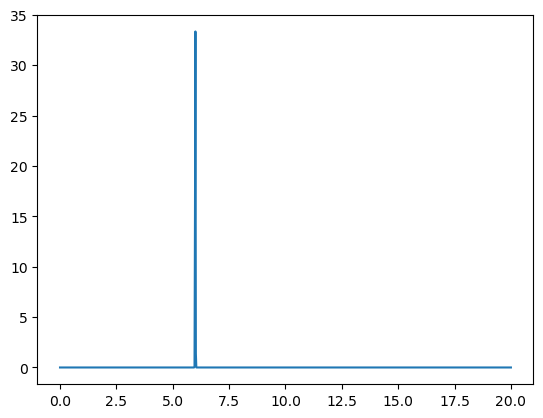

In [3]:
# example of single gaussian/stream

plt.clf()
v = np.linspace(0, 20, 1000)
sig = 0.01
f = speedDistGaussian(v, sig, 6.0)
plt.plot(v, f)

In [4]:
def streamN(v):
    sigg = 2.58
    sige = 5.6
    c_0 = 1.1
    f1 = exp(-0.5 * v**2 / sigg**2)
    f2 = c_0 * exp(- np.abs(v) / sige)
    return f1+f2

<Figure size 640x480 with 0 Axes>

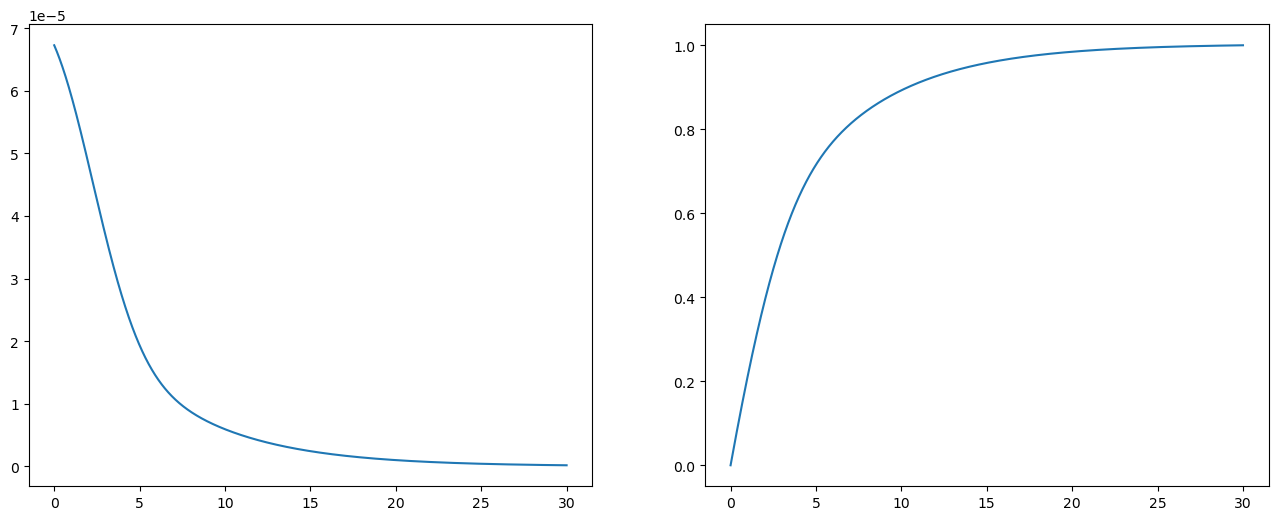

In [ ]:
#from https://iopscience.iop.org/article/10.3847/1538-4357/ad7b35
#using random constant values for now
# this is just a placeholder to find a value for N_str, i didn't read thru the full paper
# the paper produces the plots below based on radial velocity?

v = np.linspace(0, 30, 100000)[1:] # the paper goes from -20 to 20, \
    #however we don't care the direction only the speed of the stream
    # maybe need to change the maximum velocity??
y = streamN(v) / np.sum(streamN(v))
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, y)
ax[1].plot(v, y.cumsum())

v_str = np.column_stack((v, y))
#np.random.seed(0)
#v_str = np.random.choice(a=v, p=y, size = 1000)

np.random.seed(0)
v_strs = np.random.choice(a=v, p=y, size = 10000)
y = streamN(v_strs)
y = y / np.sum(y)
v_str = np.column_stack((v_strs, y))

In [39]:
v = np.linspace(0, 30, 1000)[1:]

f = []
sig = 0.005
for i in v_str:
    v_c = i[0]
    p = i[1]
    f.append(p* speedDistGaussian(v, sig, v_c))

f = np.array(f)

<Figure size 640x480 with 0 Axes>

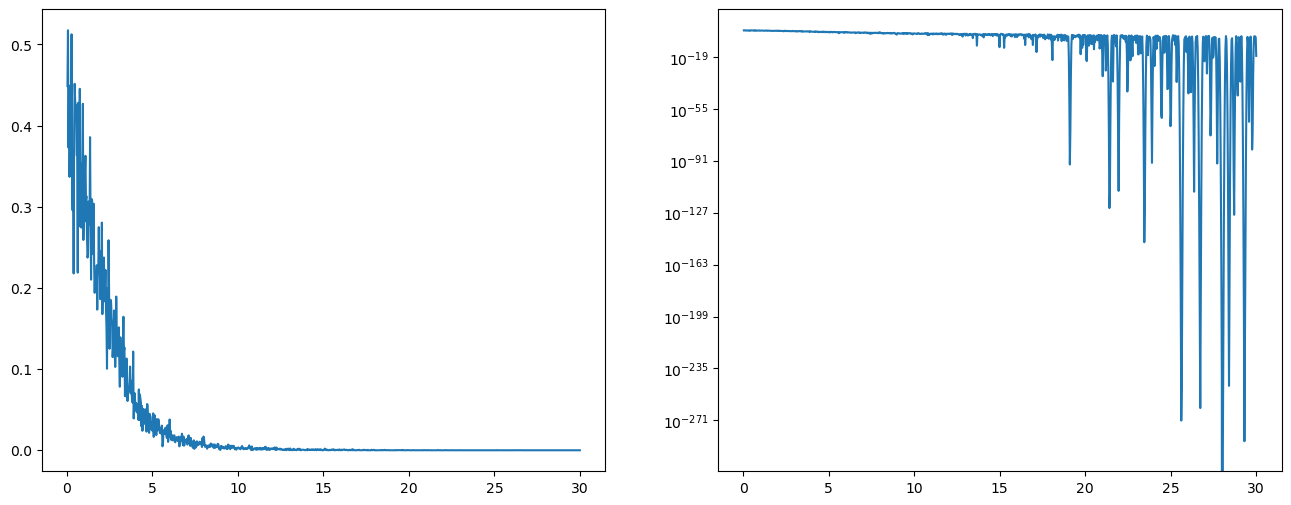

In [86]:
plt.clf()
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, f.sum(axis=0))
ax[1].semilogy(v, f.sum(axis=0))

In [47]:
v_str[:, 0]

array([3.12663127, 4.99414994, 3.61773618, ..., 5.74715747, 0.10680107,
       7.03447034], shape=(10000,))

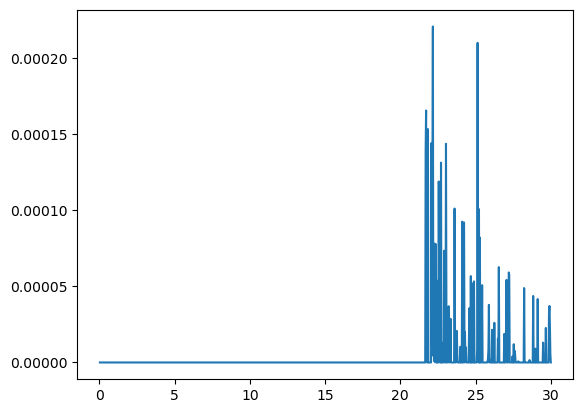

In [79]:
plt.clf()
plt.plot(v, f[np.argsort(v_str[:, 0])][::-1][:100].sum(axis=0))

In [57]:
np.argsort(v_str[:, 0])[::-1]

array([8163, 2749, 5081, ..., 7648, 3856, 2055], shape=(10000,))

In [69]:
f[np.argsort(v_str[:, 0])][::-1][:50].sum(axis=0)

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0